In [629]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL.ImImagePlugin import number
from PIL.ImageColor import colormap
from matplotlib import rcParams
from matplotlib.pyplot import tick_params
from pandas.io.sas.sas_constants import column_label_length_offset


In [630]:
'''
   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")
   3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")
   5 - default: has credit in default? (categorical: "no","yes","unknown")
   6 - housing: has housing loan? (categorical: "no","yes","unknown")
   7 - loan: has personal loan? (categorical: "no","yes","unknown")
   # related with the last contact of the current campaign:
   8 - contact: contact communication type (categorical: "cellular","telephone")
   9 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  10 - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri")
  11 - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
   # other attributes:
  12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
  14 - previous: number of contacts performed before this campaign and for this client (numeric)
  15 - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")
   # social and economic context attributes
  16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
  17 - cons.price.idx: consumer price index - monthly indicator (numeric)
  18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
  19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
  20 - nr.employed: number of employees - quarterly indicator (numeric)

  Output variable (desired target):
  21 - y - has the client subscribed a term deposit? (binary: "yes","no")

'''

'\n   Input variables:\n   # bank client data:\n   1 - age (numeric)\n   2 - job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")\n   3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)\n   4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")\n   5 - default: has credit in default? (categorical: "no","yes","unknown")\n   6 - housing: has housing loan? (categorical: "no","yes","unknown")\n   7 - loan: has personal loan? (categorical: "no","yes","unknown")\n   # related with the last contact of the current campaign:\n   8 - contact: contact communication type (categorical: "cellular","telephone")\n   9 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")\n  10 - day_

In [631]:
plt.rcParams.update({
'figure.dpi': 100,
'savefig.dpi': 300,
'figure.figsize': (20, 10),

'font.family': 'serif',
'font.size': 12,
'axes.titlesize': 12,
'axes.labelsize': 12,
'xtick.labelsize': 10,
'ytick.labelsize': 10,

'axes.spines.top': False,
'axes.spines.right': False,
'axes.grid': True,
'grid.alpha': 0.4,
'grid.linestyle': '--',
'axes.edgecolor': '#333333',

'lines.linewidth': 2,
'patch.edgecolor': 'none',

'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
})

## 1. WSTĘPNA ANALIZA DANTCH

### 1.1 *Wczytanie i podstawowy opis danych:*

In [632]:
df = pd.read_csv(r'../data/raw/bank-additional-full.csv', sep = ';')

In [633]:
df.shape

(41188, 21)

In [634]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Na początku pozbywamy się zmiennej DURATION, ponieważ w momencie wnioskowania modelu nie będziemy znali czasu trwania rozmowy**

In [635]:
df.drop(columns='duration', inplace=True)

**Zamieniamy domyślną wartość pdays = 999 oznaczając klientów z którym nie została prezentowana wcześniej oferta na wartość pdays = -1, co z biznesowego punktu widzenia będzie praktyczniejszą strategią**

In [636]:
df['pdays'] = np.where(df['pdays'] == 999, -1, df['pdays'])

In [637]:
df[(df['pdays'] == -1) & (df['previous'] != 0)]['poutcome'].value_counts()

poutcome
failure    4110
Name: count, dtype: int64

Wartości zmiennej PDAYS wydają się być mocno niespójne z innymi wskaźnikami historycznych kontraktów, co wskazywałoby na błąd śledzenia czasu w systemie CRM - należy zgłosić do odpowiedniego działu.
Pozbywamy się zmiennej pdays.m

In [638]:
df.drop(columns='pdays', inplace=True)


**Kodujemy również zmienne binarne jako integery**

In [571]:
col_names = df.columns.to_list()
num_cols = df.select_dtypes(include=np.number).columns.to_list()
cat_cols = df.select_dtypes(exclude=np.number).columns.to_list()

In [572]:
binaries = {col: df[col].unique() for col in cat_cols if df[col].nunique() == 2}
binaries

{'contact': <StringArray>
 ['telephone', 'cellular']
 Length: 2, dtype: str,
 'y': <StringArray>
 ['no', 'yes']
 Length: 2, dtype: str}

In [573]:
df['y'] = np.where(df['y'] == 'yes', 1, 0)

In [574]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  campaign        41188 non-null  int64  
 11  previous        41188 non-null  int64  
 12  poutcome        41188 non-null  str    
 13  emp.var.rate    41188 non-null  float64
 14  cons.price.idx  41188 non-null  float64
 15  cons.conf.idx   41188 non-null  float64
 16  euribor3m       41188 non-null  float64
 17  nr.employed     41188 non-null  float64
 1

**Znalizując df.info() mogłoby się wydawać, że nie mamy braków w danych, jednak będziemy musieli  obsłużyć wartości "unknown" oraz "nonexistent" na kolejnych etapach projektu.**

### 1.2 *Analiza braków i outlierów*

In [620]:
n = len(df)
unknowns = {
    name: round(len(df[df[name].astype(str).str.lower() == 'unknown']) / n, 3)
    for name in col_names
    if (df[name].astype(str).str.lower() == 'unknown').any()
}
print(unknowns)

{'job': 0.008, 'marital': 0.002, 'education': 0.042, 'housing': 0.024, 'loan': 0.024}


In [621]:
nonexists = {
    name: round(len(df[df[name].astype(str).str.lower() == 'nonexistent']) / n, 3)
    for name in col_names
    if (df[name].astype(str).str.lower() == 'nonexistent').any()
}
print(nonexists)

{'poutcome': 0.863}


In [577]:
for col in unknowns.keys():
    print(df[col].value_counts())

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


In [627]:
df[df['poutcome'] == 'nonexistent'][['previous', 'poutcome']].value_counts()

previous  poutcome   
0         nonexistent    35563
Name: count, dtype: int64

In [581]:
df.drop(columns='default', inplace=True)

Zmienna DEFAULT jest skrajnie niezbalansowana - decydujemy się ją usunąć

In [623]:
col_names = df.columns.to_list()
num_cols = df.select_dtypes(include=np.number).columns.to_list()
cat_cols = df.select_dtypes(exclude=np.number).columns.to_list()
len(num_cols)

8

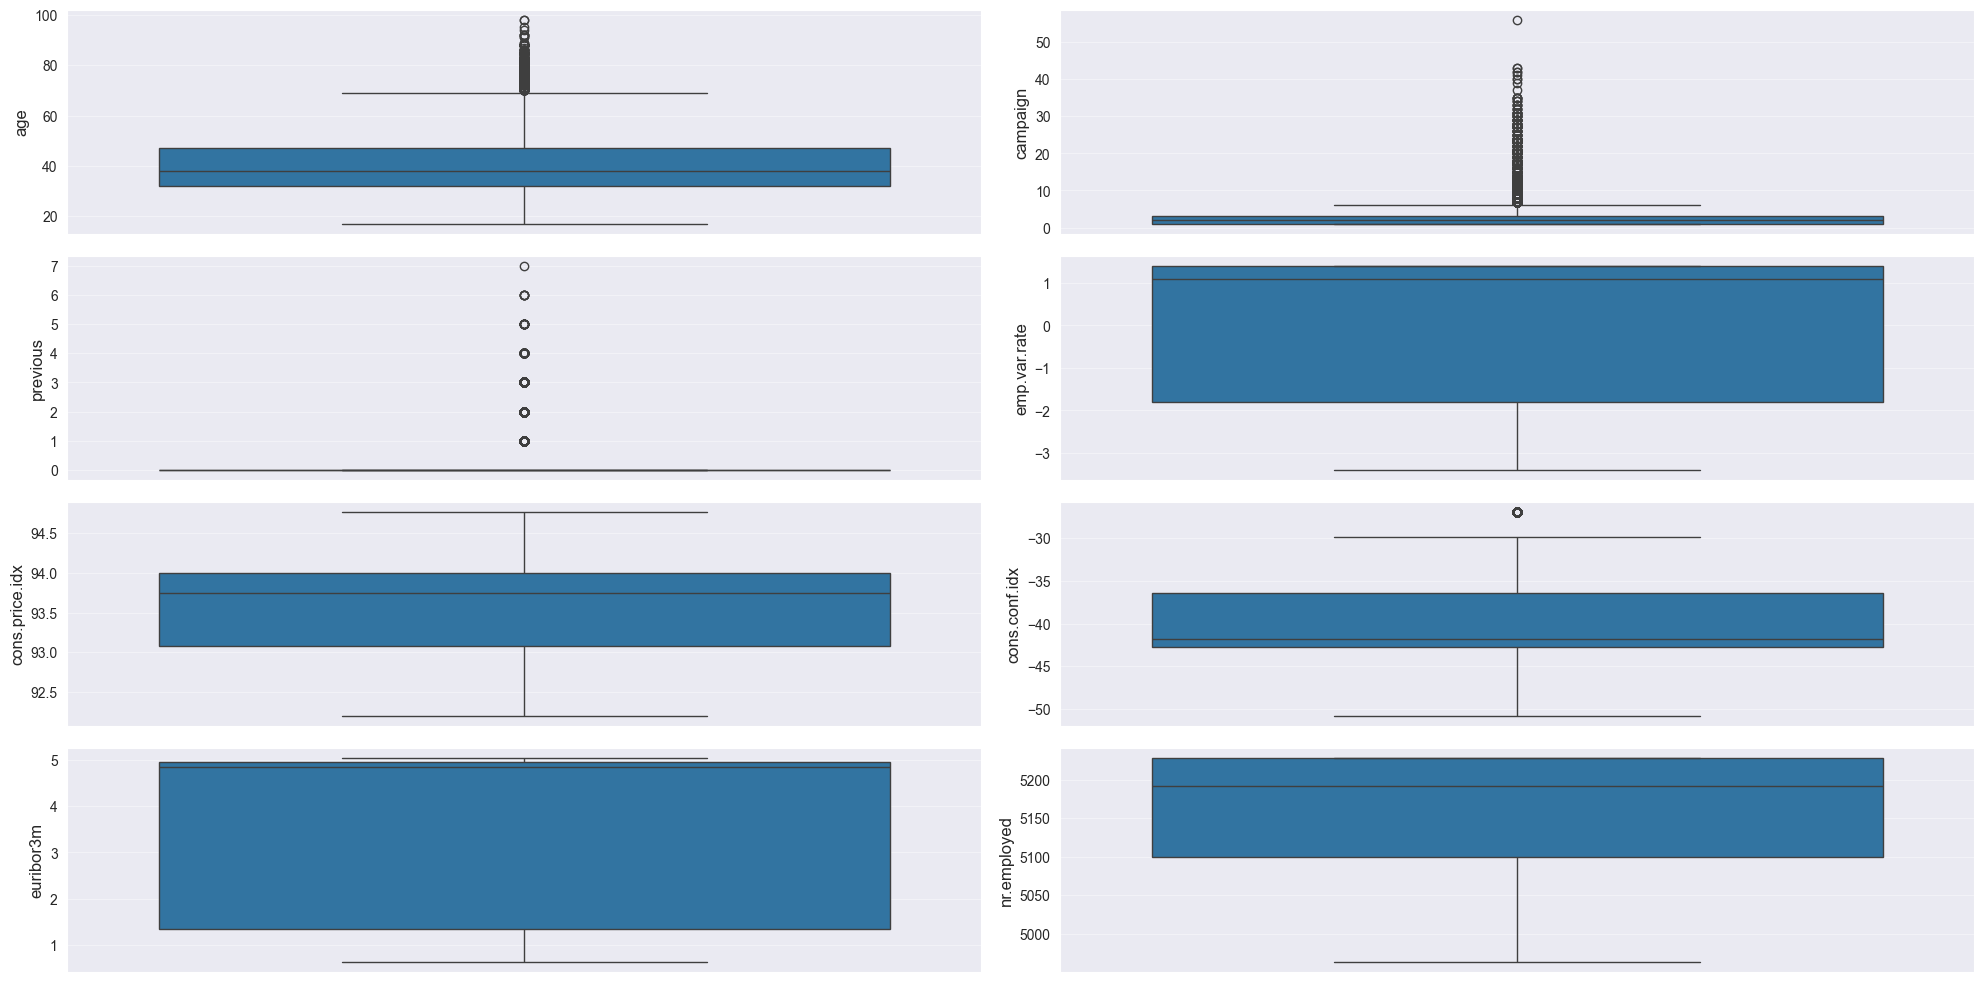

In [624]:
fig, axes = plt.subplots(int(np.ceil(len(num_cols) / 2)), 2)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
plt.tight_layout()
plt.show()

In [625]:
def get_outlier_ranges(df, cols, multip=1.5):
    non_out_ranges = dict()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + multip*IQR
        lower = Q1 - multip*IQR
        non_out_ranges[col] = (lower, upper)
    return non_out_ranges

def get_outliers_info(df, col, lower, upper):
    mask = (df[col] > upper) | (df[col] < lower)
    n_outliers = sum(mask)
    percentage = n_outliers / n
    print(f"{col} [{lower}, {upper}]: {n_outliers} outliers - {(percentage):.3f} of pop")

In [626]:
non_out_dict = get_outlier_ranges(df, num_cols)
for col in num_cols:
    lower, upper = non_out_dict[col]
    get_outliers_info(df, col, lower, upper)

age [9.5, 69.5]: 469 outliers - 0.011 of pop
campaign [-2.0, 6.0]: 2406 outliers - 0.058 of pop
previous [0.0, 0.0]: 5625 outliers - 0.137 of pop
emp.var.rate [-6.6000000000000005, 6.200000000000001]: 0 outliers - 0.000 of pop
cons.price.idx [91.69650000000001, 95.3725]: 0 outliers - 0.000 of pop
cons.conf.idx [-52.150000000000006, -26.949999999999992]: 447 outliers - 0.011 of pop
euribor3m [-4.081499999999999, 10.3865]: 0 outliers - 0.000 of pop
nr.employed [4905.6, 5421.6]: 0 outliers - 0.000 of pop


**Ze względu na dużą prawoskońsność w kilku zmiennych decydujemy się nie wykorzysywać metody IQR - spowodowałoby to pozbycie się zbyt dużej liczby obserwacji. Zamiast tego skorzystamy z metody winsoryzacji na poziomie 0.01% i 99.9% - pozwoli nam to "przytrymować" wartości skrajne powstałe w wyniku szumu bądź błędu pomiaru, pozostawiając tym samym wszystkie deficytowe obserwacje klasy pozytywnej zmiennej y.**

### 1.3 *Podstawowe statystyki*

In [587]:
df.describe().round(2)

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,2.56,0.17,0.08,93.58,-40.50,3.62,5167.04,0.11
std,10.40,2.71,0.49,1.57,0.58,4.62,1.73,72.25,0.32
min,19.00,1.00,0.00,-3.40,92.20,-50.00,0.63,4963.60,0.00
25%,32.00,1.00,0.00,-1.80,93.08,-42.70,1.34,5099.10,0.00
50%,38.00,2.00,0.00,1.10,93.75,-41.80,4.86,5191.00,0.00
75%,47.00,3.00,0.00,1.40,93.99,-36.40,4.96,5228.10,0.00
max,86.00,29.00,4.00,1.40,94.77,-26.90,5.04,5228.10,1.00


In [588]:
skewness = df[num_cols].skew()
print(skewness)

age               0.770620
campaign          4.251960
previous          3.589169
emp.var.rate     -0.724096
cons.price.idx   -0.230888
cons.conf.idx     0.310014
euribor3m        -0.709188
nr.employed      -1.044262
y                 2.450330
dtype: float64


**Badamy zmienność naszych zmiennych ciągłych za pomocą współczynnika zmienności:**

In [589]:
cv = df[num_cols].apply(lambda x: x.std() / x.mean())
print(cv)

age                0.259982
campaign           1.056238
previous           2.833032
emp.var.rate      19.184834
cons.price.idx     0.006186
cons.conf.idx     -0.114145
euribor3m          0.478958
nr.employed        0.013983
y                  2.806584
dtype: float64


**Badamy zmienność naszych zmiennych kategorycznych za pomocą entropi:**

In [590]:
for col in cat_cols:
    print(f"{col}: {(stats.entropy(df[col].value_counts(normalize=True)) / (np.log2(len(df[col].value_counts())))):.3f}")

job: 0.587
marital: 0.571
education: 0.586
housing: 0.689
loan: 0.426
contact: 0.656
month: 0.553
day_of_week: 0.693
poutcome: 0.299


**Nie wszystkie zmienna cechują się wysoką zmienności, jednak nie dycydujemy się na usunięcie zadnej z niej bo algorytmu drzewiaste potrafią również z takich zmiennych "wyciągnąć" wiele informacji ustalając odpowidnią granicę decyzyjną**

In [591]:
target_values = df['y'].value_counts(normalize=True)
target_values

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

**Mamy do czynienia z silnym niezbalanosowaniem zmiennej celu.
Dlatego skorzystamy z metody oversamplingu, w celu możliwie optymalnego wykorzystania obserwacji pozytywnych**

### 1.3. *Wstępne wnioski*

- Spora część naszych cech ma silnie prawostronny rozkład. Z tego powodu oraz z powodu potrzeby wysokiej interpretowalność jako nasz model decydujemy się wykorzystać algorytm lasu losowego, który jest odporny na wartości skrajne i skośność rozkładu. Oszczędzi nam to dodatkowo pracy w kwestii transforamacji zmiennych, a dodatkowo będziemy w stanie wskazać czynniki, które w największym stopniu wpłynęły na decyzje modelu, co jest wyjąstkowo porządane w sektorze bankowym. Dodatkowo liczymy, że drzewo zgrabnie "podzieli" klientów na tych którzy brali udział w poprzedniej kampanii i na tych co udziału nie brali.
- Aby zbudować model oparty na tej metodzie będziemy musieli zakodować nasze zmienne kategoryczne stosując one-hot-encoding
 - Niezbalansowana zmienna celu dodatkowo wymusza na nas zastosowanie metodę nadpróbkowania klasy mnieszościowej.

**********************************

## 2. WIZUALIZACJE

### 2.1. *Wizualizacje rozkładów*

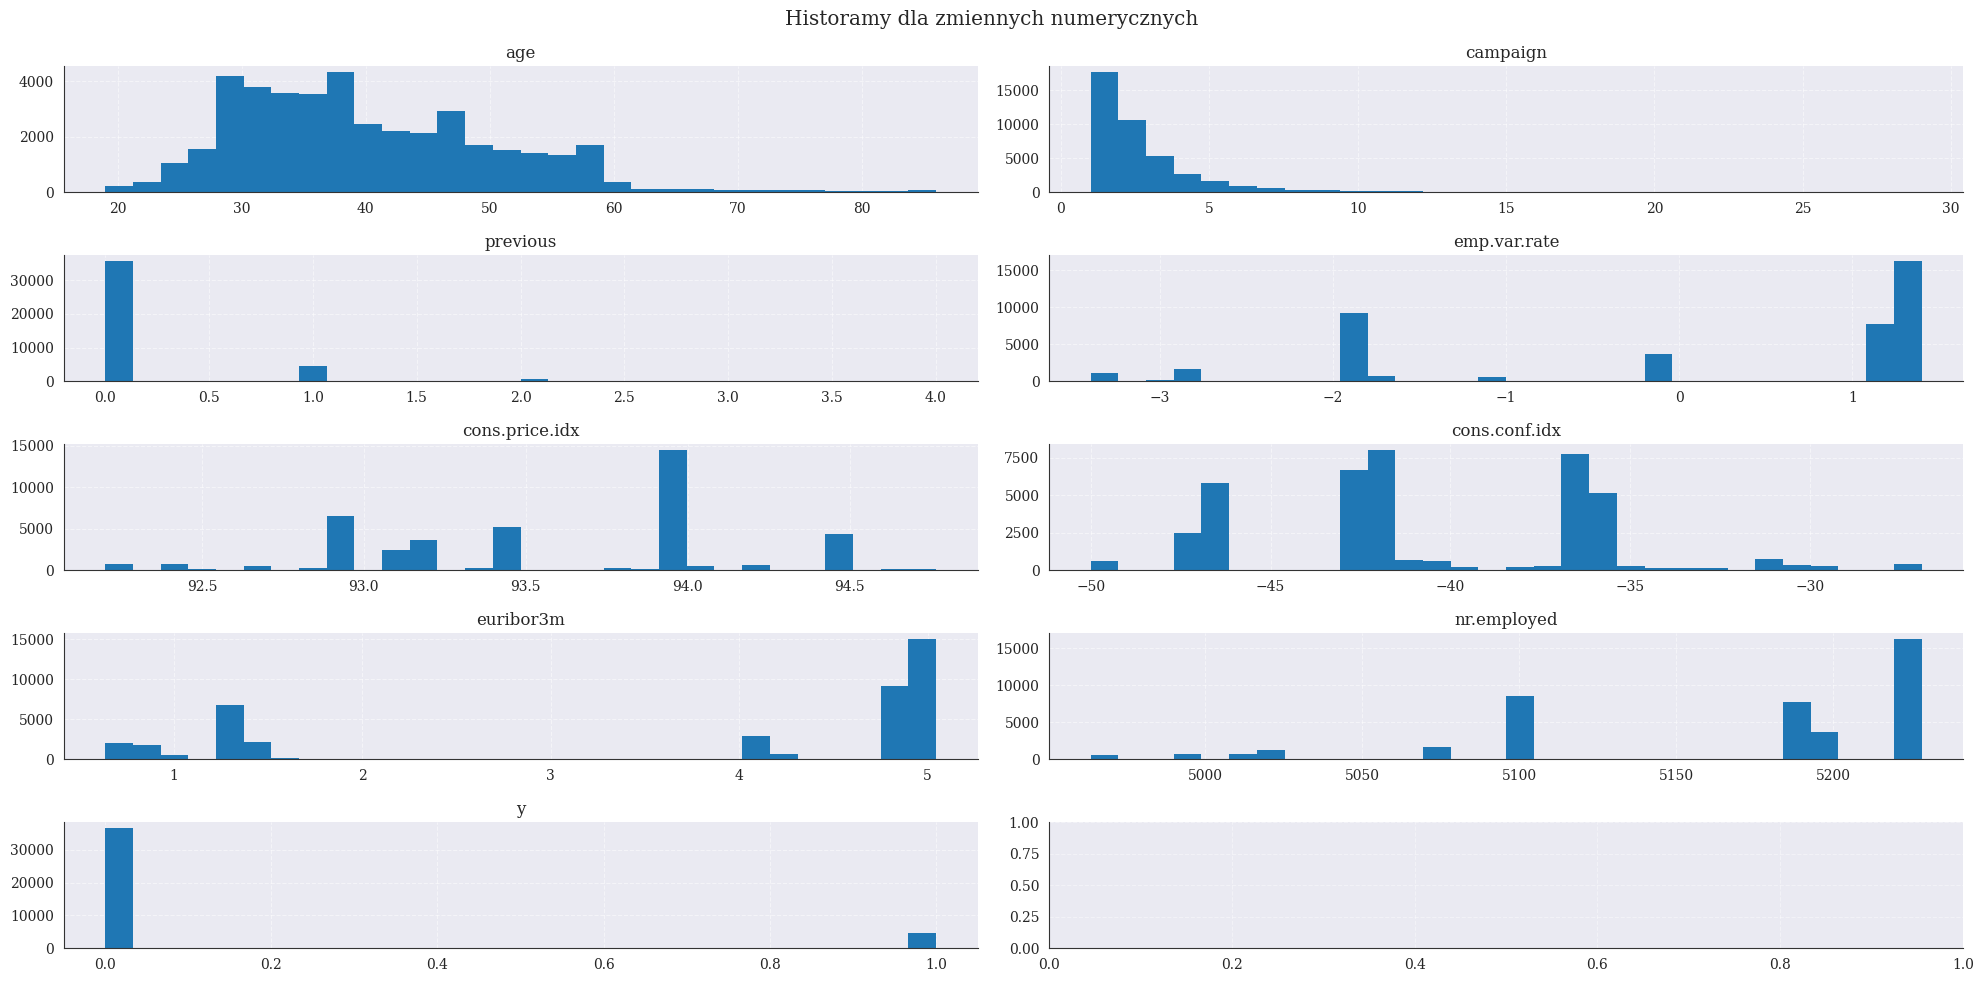

In [592]:
fig, axes = plt.subplots(int(np.ceil(len(num_cols) / 2)), 2)
axes = axes.flatten()

for i, ax in enumerate(axes[:-1]):
    ax.hist(df[num_cols[i]], bins=30)
    ax.set_title(num_cols[i])
    ax.grid(True, alpha=0.5)

plt.suptitle("Historamy dla zmiennych numerycznych")
plt.tight_layout()
plt.show()

In [593]:
df.select_dtypes(include='number').kurt()

age                0.689343
campaign          26.654473
previous          16.107034
emp.var.rate      -1.062632
cons.price.idx    -0.829809
cons.conf.idx     -0.368194
euribor3m         -1.406803
nr.employed       -0.003760
y                  4.004312
dtype: float64

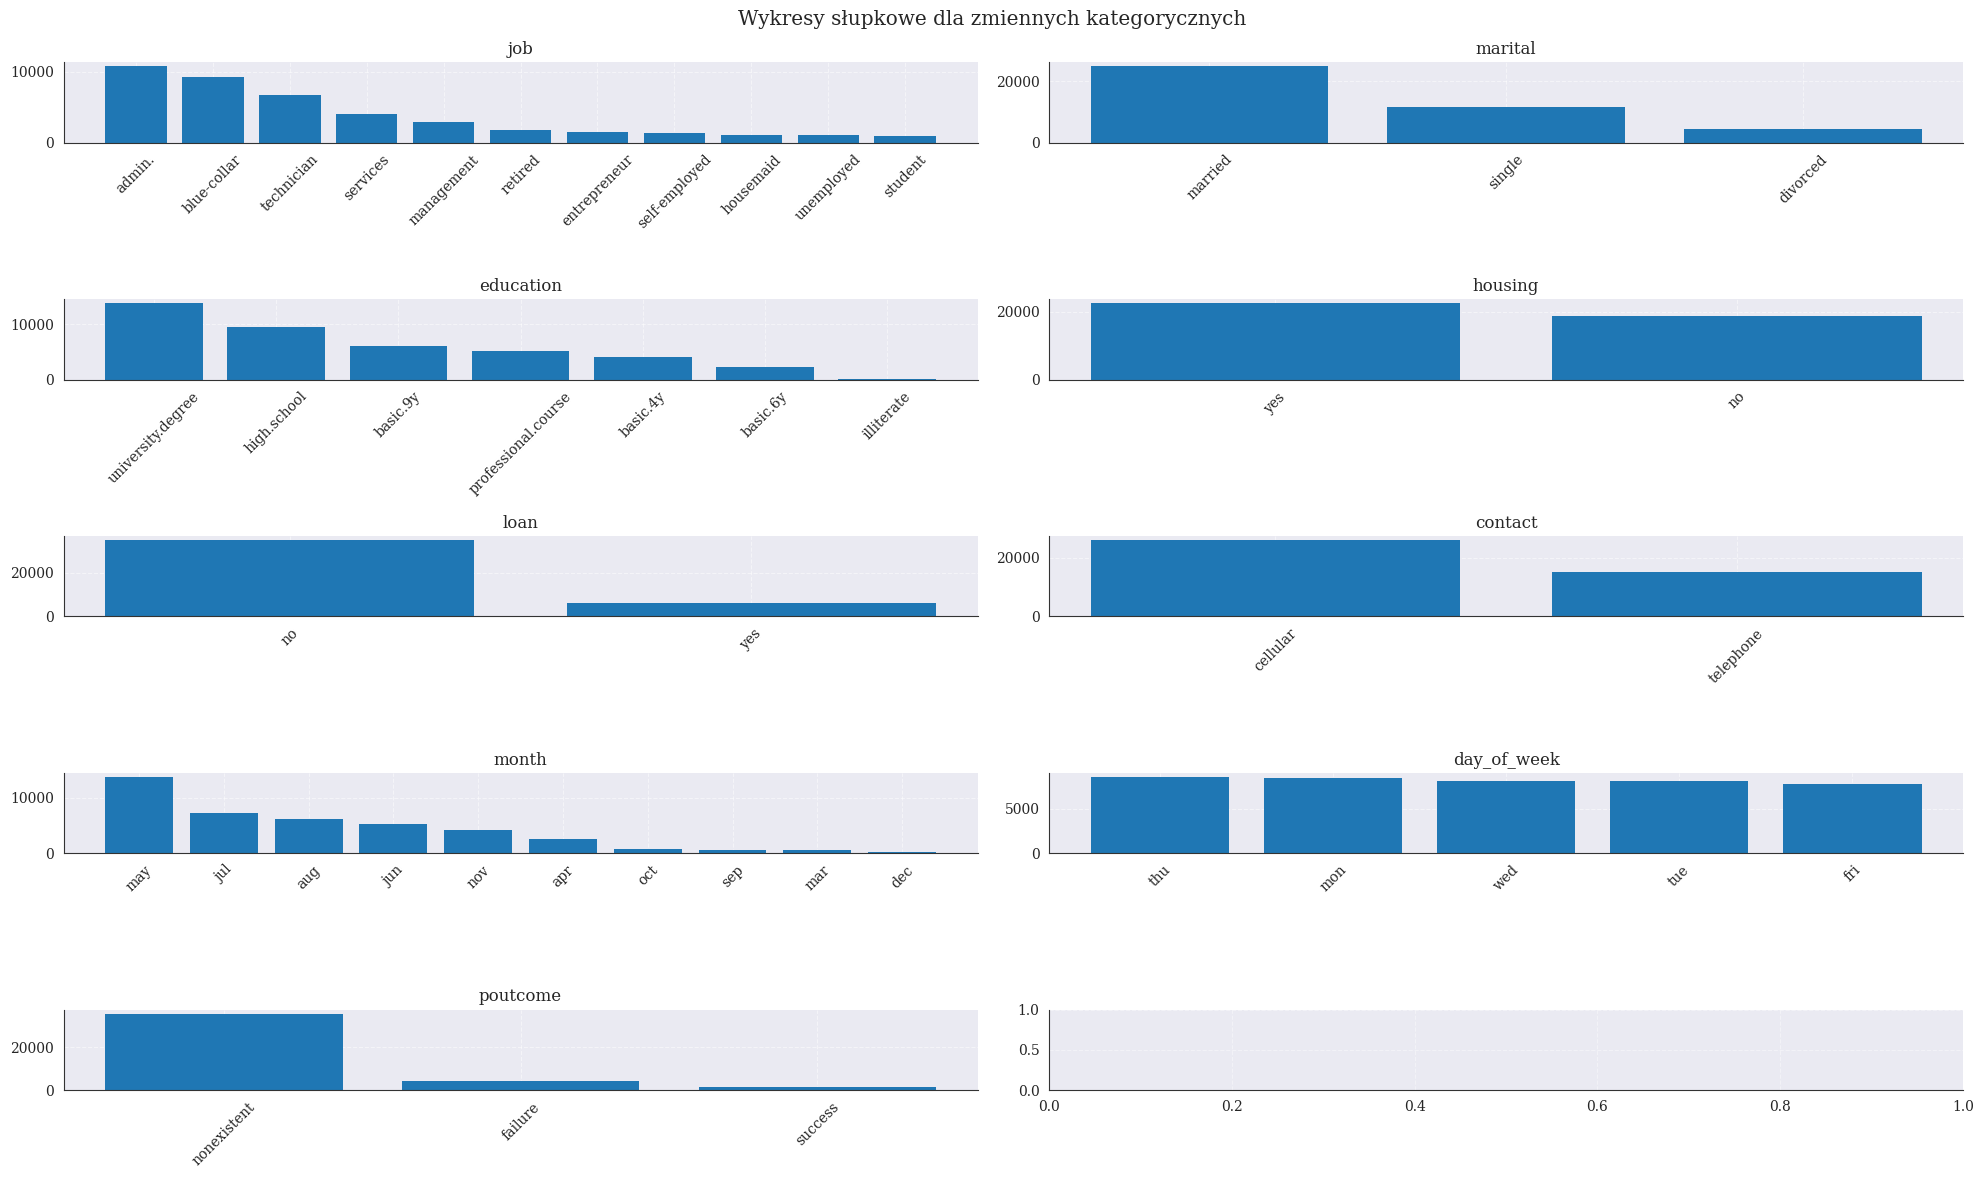

In [594]:
fig, axes = plt.subplots(int(np.ceil(len(cat_cols) / 2)), 2, figsize=(20, 12))
axes = axes.flatten()

for i, ax in enumerate(axes[:-1]):
    counts = df[cat_cols[i]].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(cat_cols[i])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.5)

plt.suptitle("Wykresy słupkowe dla zmiennych kategorycznych")
plt.tight_layout()
plt.show()

Wykresy zmiennych kategorycznych nają dam dobry pogłąd na ogólny rozkad tych zmiennych. Do rozkładów wartych odnotowania jest fakt, że analizawane przypadki kampanii miałe w głównej mierze miejsce w trakcie miesięcy letnich. A sama oferta była kierowania do osób będących w związku małżeńskim.

### 2.2. *Analiza zależności*

In [595]:
corr_mtx = df.select_dtypes(include='number').corr()

In [596]:
corr_data = df.copy()
corr_data = corr_data.select_dtypes(include='number')
corr_data['has_history'] = np.where(corr_data['previous'] == 0, 0, 1)
corr_data.drop(columns=['previous'], inplace=True)
corr_matrix = corr_data.corr()

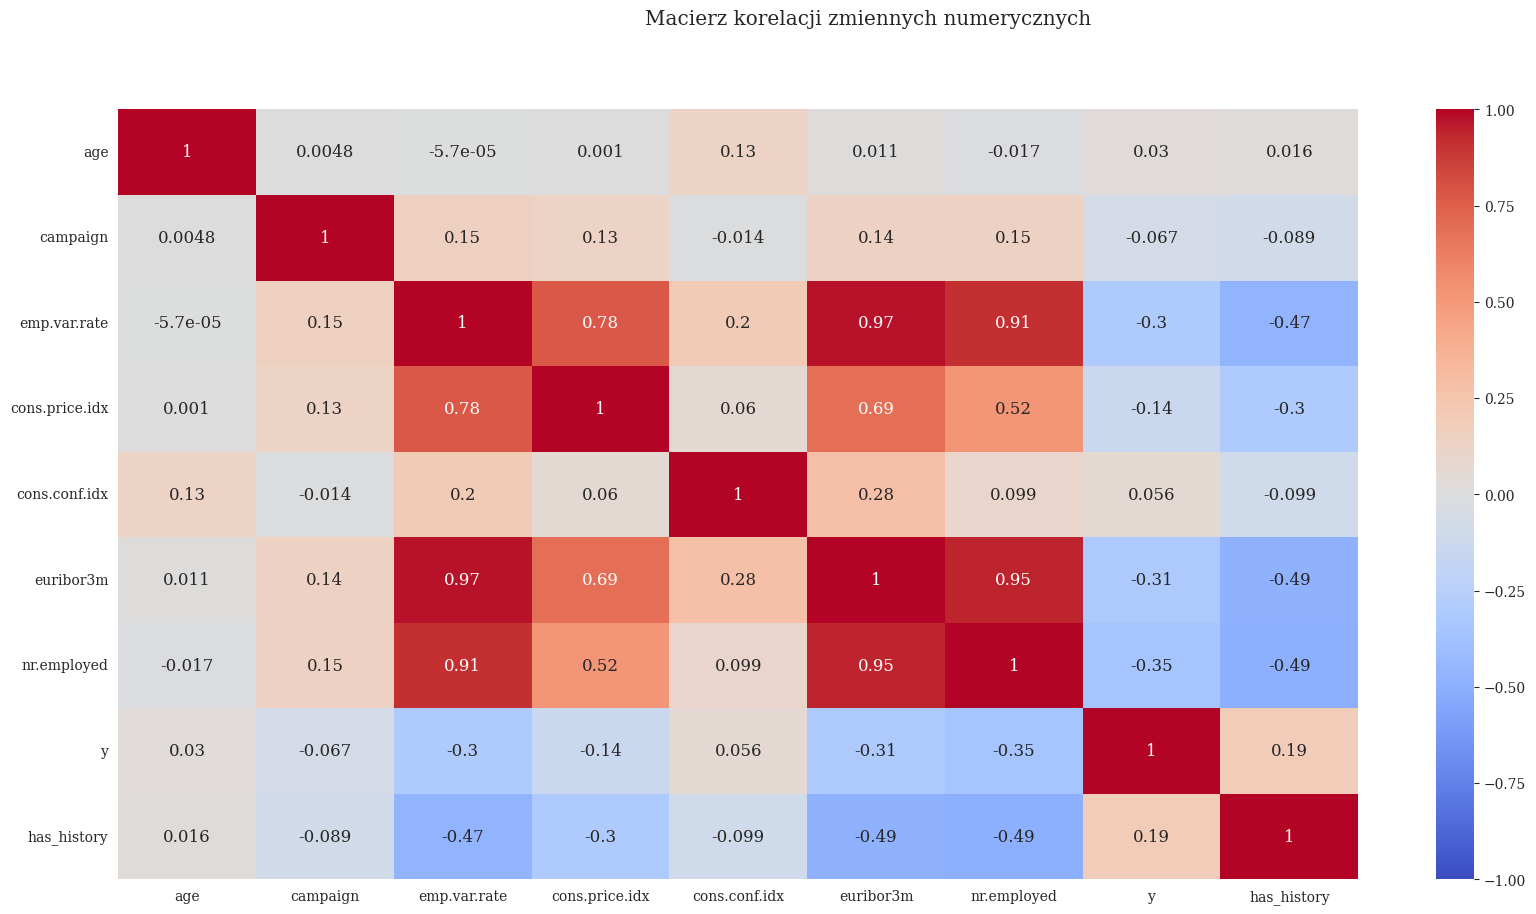

In [597]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.suptitle('Macierz korelacji zmiennych numerycznych')
plt.show()

Zmienne EMP.VAR.RATE, EURIBOR3M oraz NR.EMPLOYED są silnie skorolowane liniowo ze sobą. Kierując się zasada brzytwy ockhama oraz potrzebą oceny wpływu każdego współczynnika z osobna, decydujemy się usunąć zmienną EMP.VAR.RATE ze względu na najsłabszą korelację ze zmienną celu. Pozbywamy się także zmiennej NR.EMPLOYED, która charakteryzuje się mniejszą granularnością i sensem biznesowym dla projektu od zmiennej EURIBOR3M. Liczymy na to, że dzięki wiekszej zmienności EURIBOR3M w zbiorze treningowym, lepiej dopasuje się ona do niewidzianych danych.

Pozostałe zmienne ekonomiczne nie charakteryzują się tak silnym związkiem ze zmienną celu, jednak ich korelacja z innymi zmiennymi ekonomicznych jest zauważalna.

Reszta zmiennych numerycznych jest w bardzo niewielkim stopniu skorelowane liniowo ze zmienną celu oraz z samymi sobą. Najbardziej skorelowana ze zmienną y jest nasza "sztuczna" zmienna związana z uczesnictwem klienta w poprzednich kampaniach.

In [598]:
df.drop(columns=['emp.var.rate', 'nr.employed'], inplace=True)

col_names = df.columns.to_list()
num_cols = df.select_dtypes(include=np.number).columns.to_list()
cat_cols = df.select_dtypes(exclude=np.number).columns.to_list()

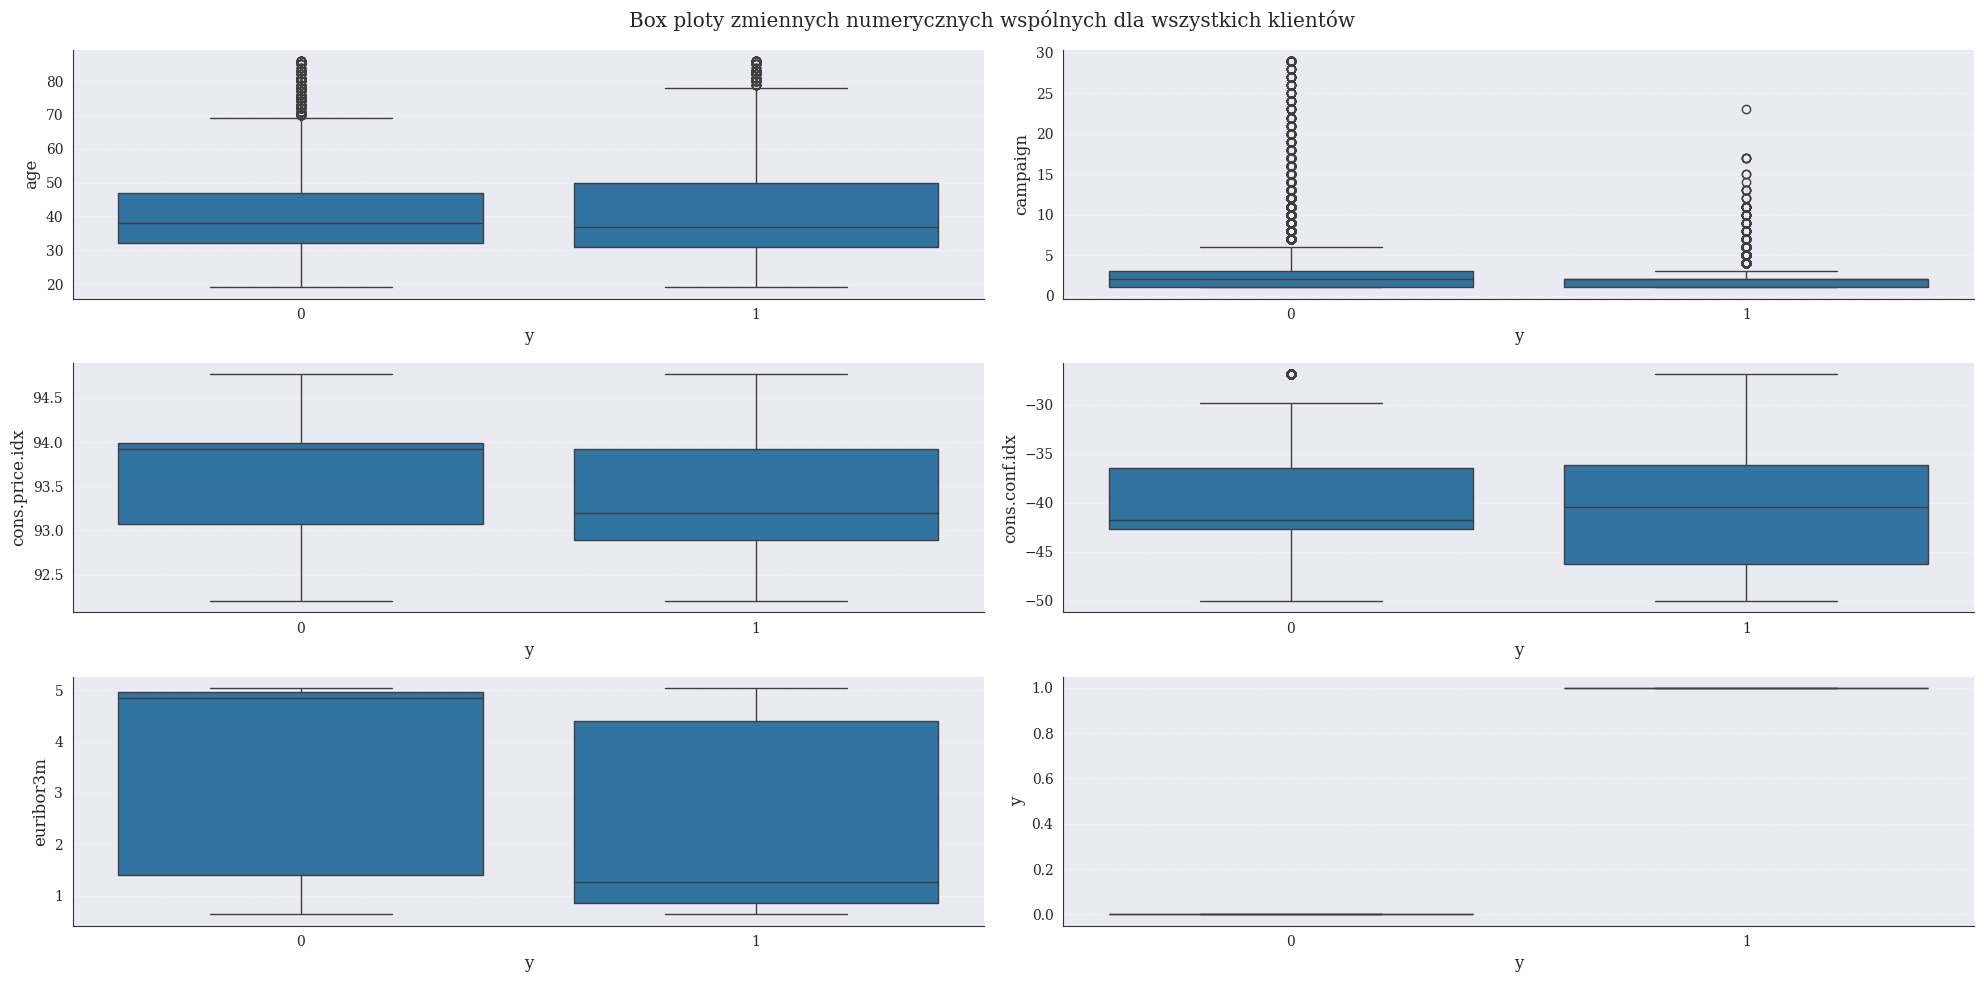

In [599]:
standard_num_cols = num_cols[:]
standard_num_cols.remove('previous')
fig, axes = plt.subplots(int(np.ceil(len(standard_num_cols) / 2)), 2)
axes = axes.flatten()

for i, col in enumerate(standard_num_cols):
    sns.boxplot(x=df['y'], y=df[col], ax=axes[i])

plt.suptitle('Box ploty zmiennych numerycznych wspólnych dla wszystkich klientów')
plt.tight_layout()
plt.show()

Największa dysproporcja dotyczy wskaźnika EURIBOR3M – sukcesy kampanii grupują się zdecydowanie wokół drastycznie niskich stóp procentowych, podczas gdy porażki dominują przy stawkach maksymalnych, ta zależność pokazuje, że popyt na lokaty bankowe jest w tym przypadku wielce elastyczny względem ryzyka rynkowego, a nie samej stopy zwrotu. Drugą wyraźną różnicę widać w zmiennej campaign, gdzie udane transakcje zamykają się w pierwszych kilku próbach, a dla klasy y=0 widzimy efekt "zajeżdżania" klientów (outliery dobijające do 30 telefonów). Rozkłady pozostałych zmiennych, takich jak wiek czy inflacja, mocno się ze sobą pokrywają i na poziomie samych median nie wykazują tak oczywistej siły dyskryminacyjnej.

In [600]:
presentation_df = df.copy()
presentation_df['has_history'] = np.where(presentation_df['previous'] == 0, 'no', 'yes')

In [601]:
df_with_history = presentation_df[presentation_df['has_history'] == 'yes']
cross_table = pd.crosstab(df_with_history['y'], df_with_history['previous'])
cross_table

previous,1,2,3,4
y,,,,
0,3594,404,88,40
1,967,350,128,54


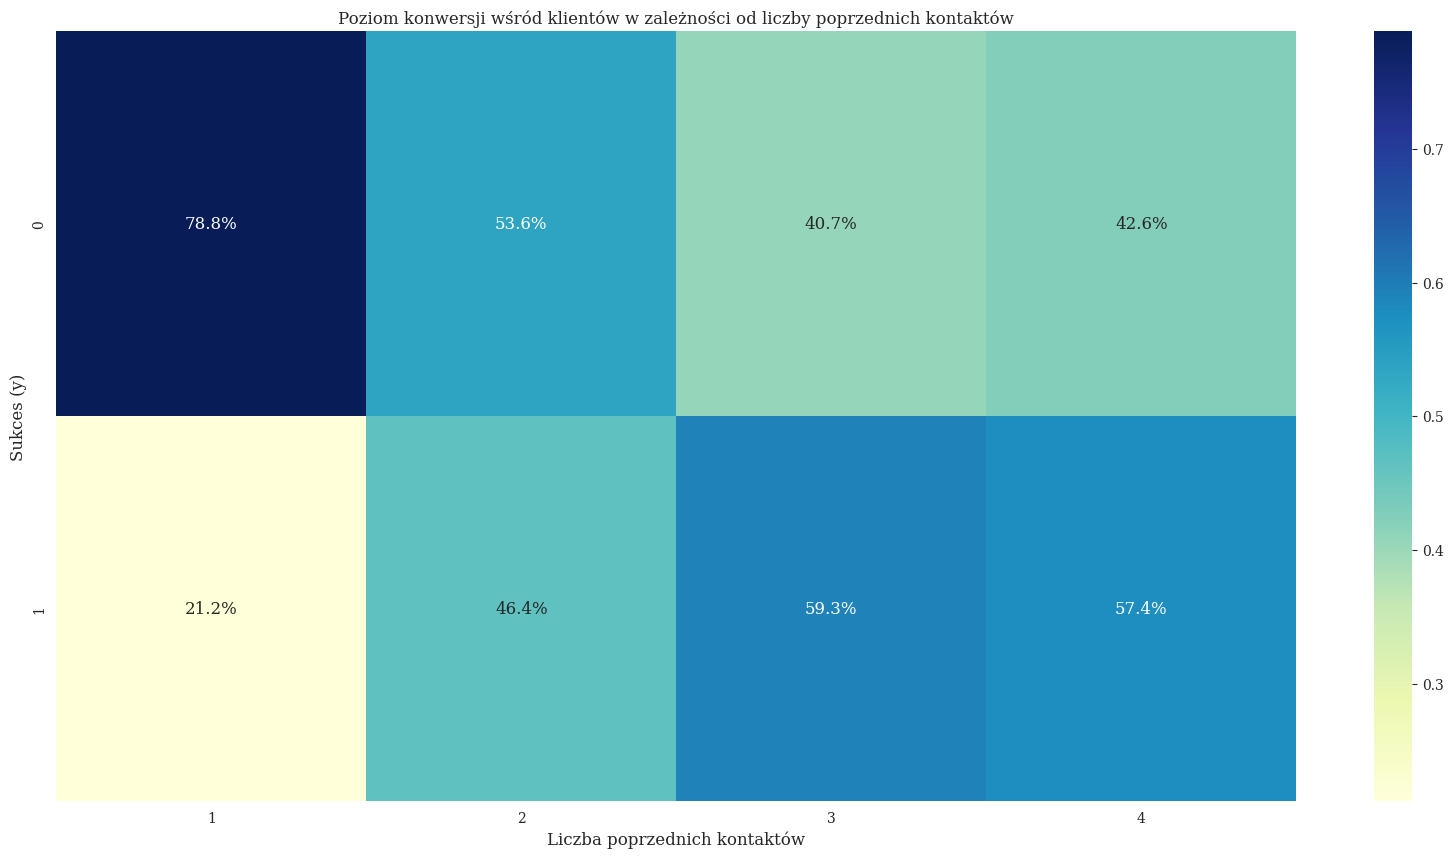

In [602]:
cross_table_pct = pd.crosstab(
    df_with_history['y'],
    df_with_history['previous'],
    normalize='columns'
)
sns.heatmap(
    cross_table_pct,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
)
plt.title("Poziom konwersji wśród klientów w zależności od liczby poprzednich kontaktów")
plt.ylabel("Sukces (y)")
plt.xlabel("Liczba poprzednich kontaktów")
plt.show()

Wraz ze wzrostem liczby poprzednich kontaktów z klientem z jednego do trzech, poziom konwersji drastycznie rośnie z poziomu 21.2% do aż 59.3%. Przy czwartym kontakcie następuje jednak stabilizacja i lekki spadek skuteczności, co sugeruje osiągnięcie punktu nasycenia, po którym dalsze ponawianie prób nie przynosi już korzyści marketingowych.

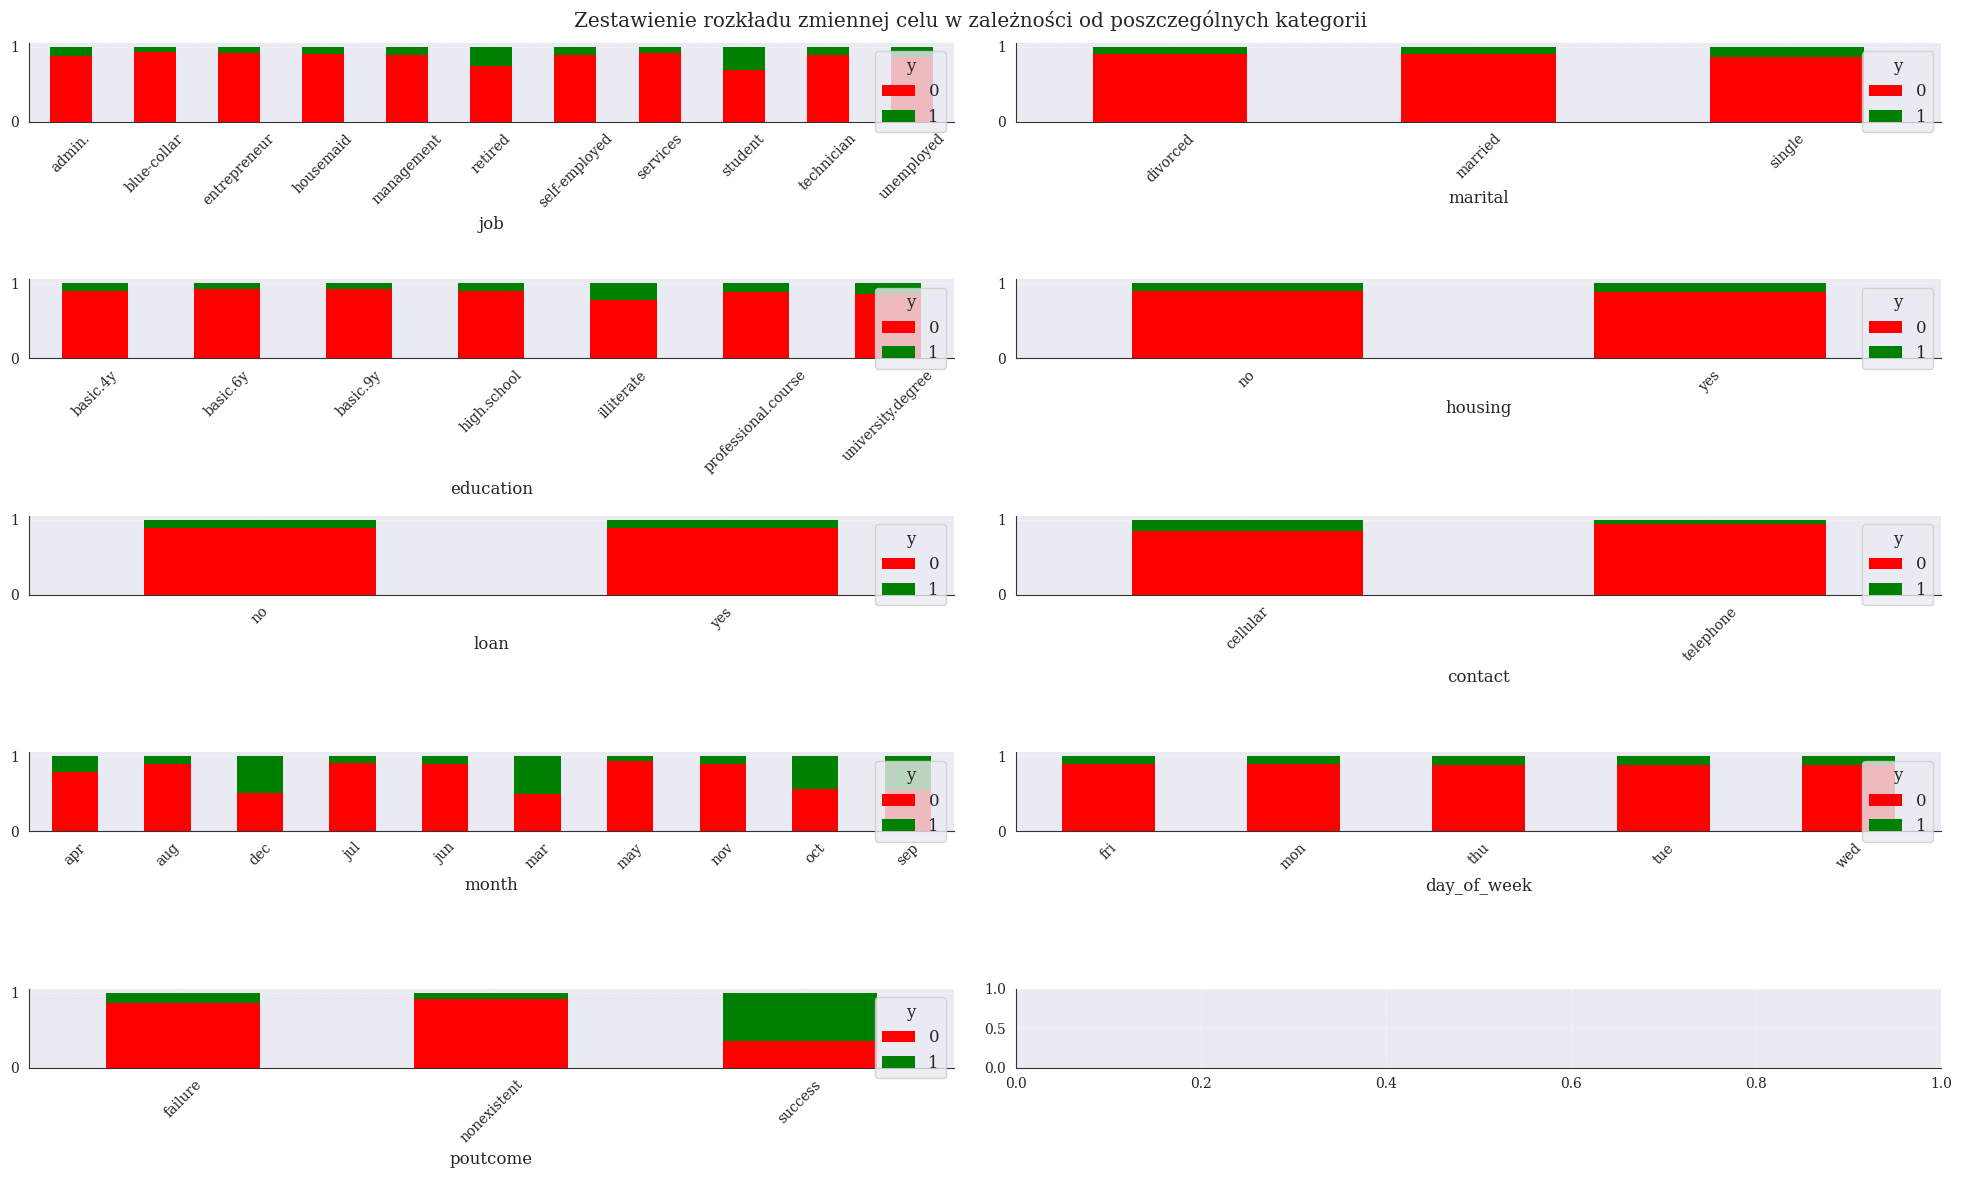

In [603]:
fig, axes = plt.subplots(int(np.ceil(len(cat_cols) /2 )), 2, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross_table = pd.crosstab(df[col], df['y'])
    normed_cross_table = cross_table.div(cross_table.sum(axis=1), axis=0).round(3)
    normed_cross_table.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=["red", "green"]
    )
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Zestawienie rozkładu zmiennej celu w zależności od poszczególnych kategorii')
plt.tight_layout()
plt.show()

Akcja marketingowa miała szczególnie wysoki współczynik konwersji:
- wśród studentów i osób na emeryturze
- wśród osób bez kredytu mieszkaniowego
- wśród klientów, którzy skorzystali z oferty lokaty we wcześniejszej kampanii
- w czasie marcowych, wrześniowych, październikowych i grudniowych kampanii - należy jednak mieć na uwadze, że były tymi o najmniejszej liczności w badanej próbie, więc zależność ta może być złudna

### 2.3. *Wizualizacje zaawansowane*

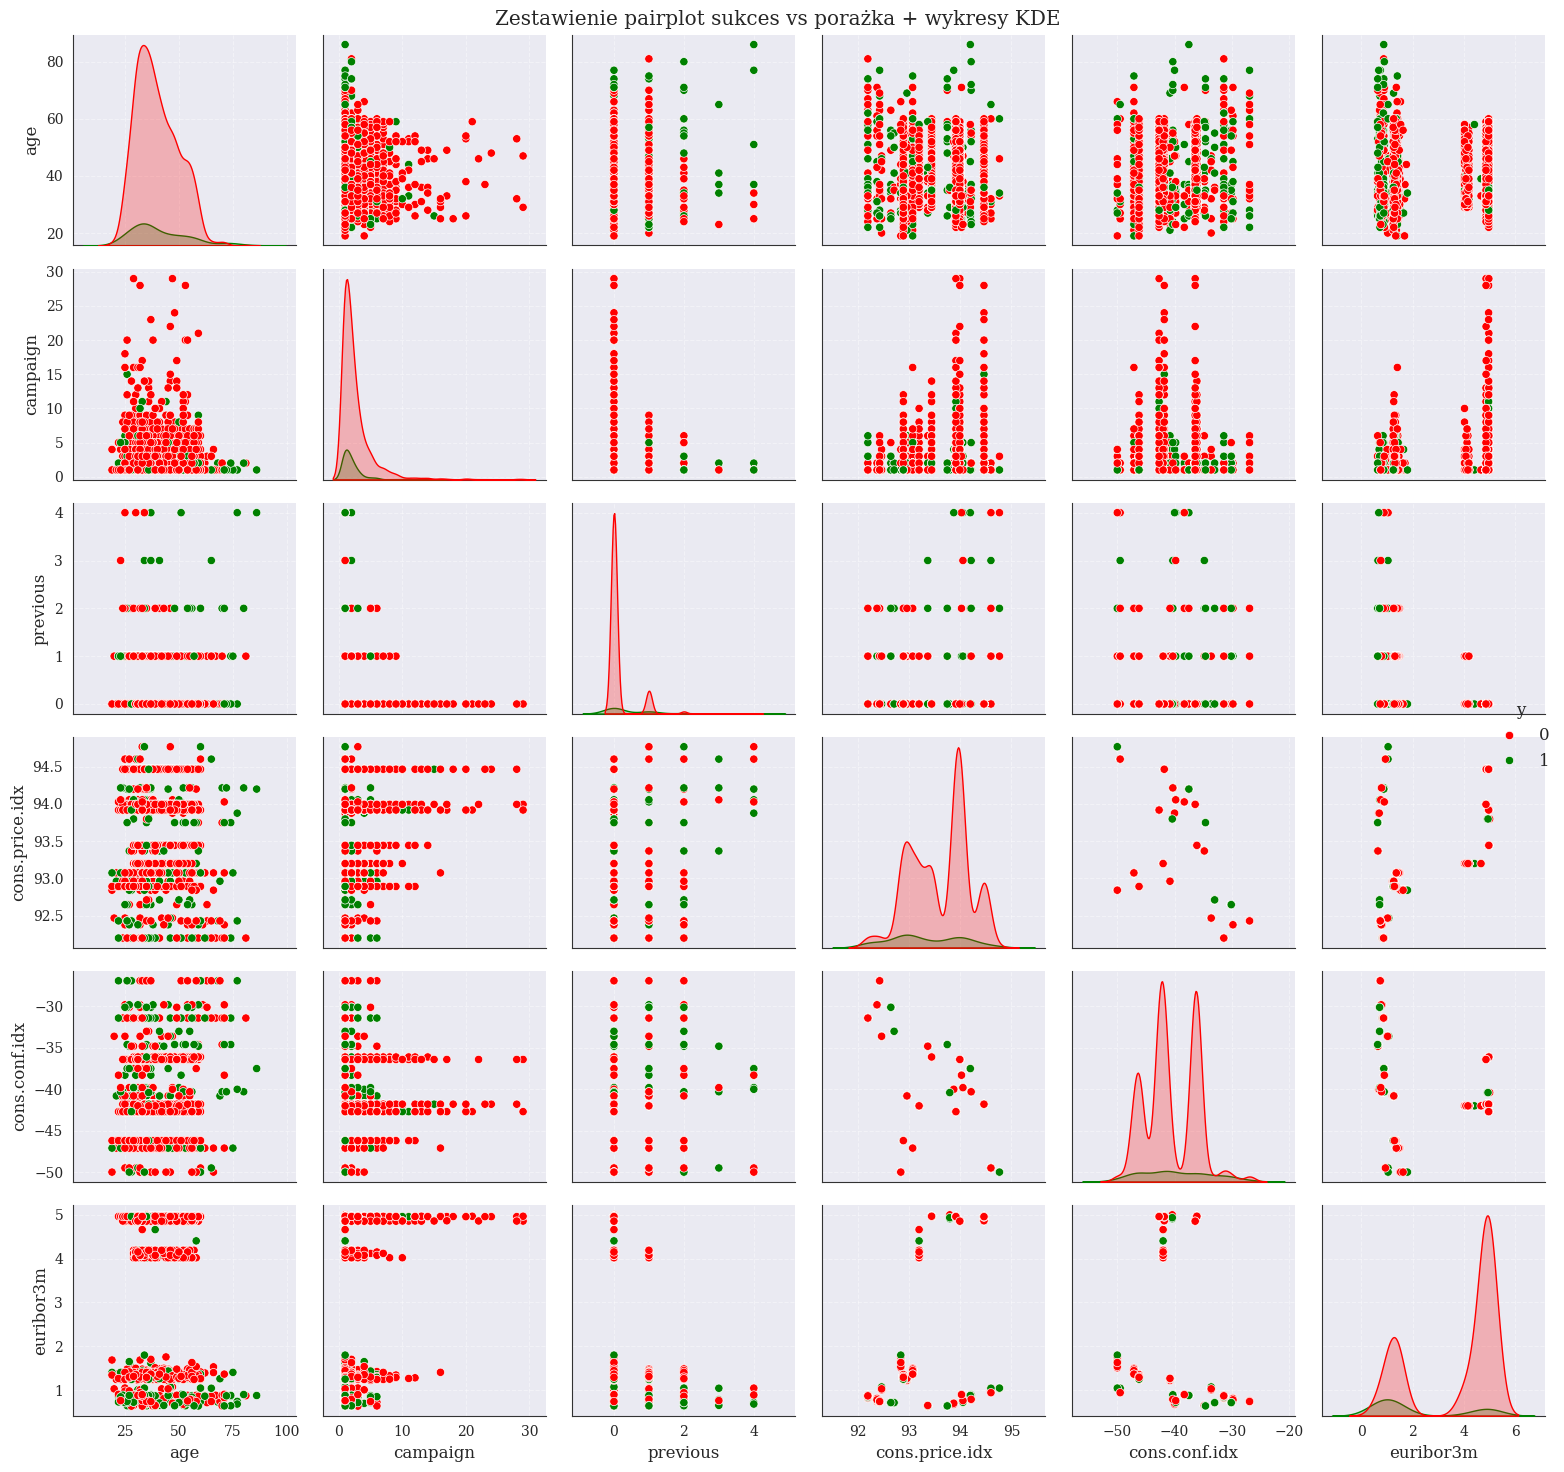

In [604]:
sns.pairplot(
    df[num_cols].sample(n=2000, random_state=42),
    hue='y',
    diag_kind='kde',
    palette=['red', 'green']
)
plt.suptitle('Zestawienie pairplot sukces vs porażka + wykresy KDE')
plt.tight_layout()
plt.show() #on sie w końcu wegeneruje, spokojnie

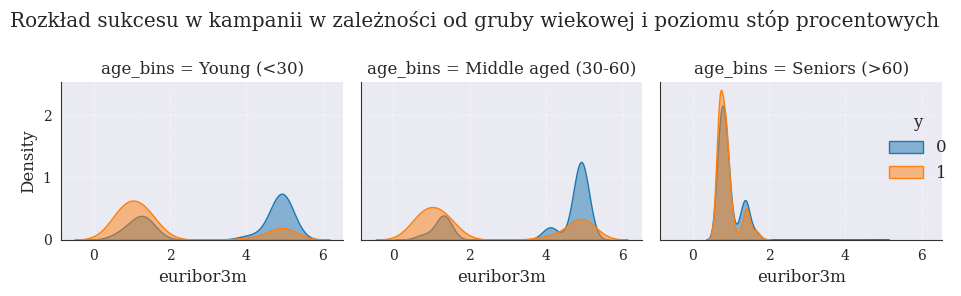

In [605]:
presentation_df['age_bins'] = pd.cut(
    presentation_df['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Middle aged (30-60)', 'Seniors (>60)']
)
g = sns.FacetGrid(
    data=presentation_df,
    col='age_bins',
    hue='y'
)
g.map(
    sns.kdeplot,
    'euribor3m',
    fill=True,
    common_norm=False,
    alpha=0.5,
    warn_singular=False
)
g.add_legend()

plt.suptitle('Rozkład sukcesu w kampanii w zależności od gruby wiekowej i poziomu stóp procentowych')
plt.tight_layout()
plt.show()

Z analizy zestawienia grup wiekowych wyciągamy nastęujące wnioski:
Osoby młode przy wysokich stopach masowo odmawiają, bo w okresie wyżu gospodarczego rzadko dysponują wolnymi nadwyżkami finansowymi. Zaskakujący skok sukcesów notują przy niskich stopach, co sugeruje uleganie presji call center
Seniorzy reagują skrajnie nieliniowo, masowo zakładają lokaty w czasach niskich stóp (kryzysu). Nie gonią za rentownością, lecz szukają bezpiecznej przystani dla kapitału.
Z kolei osoby w średnim wieku zachowują się najbardziej przewidywalnie. Przy niskim Euriborze twardo odrzucają ofertę, natomiast ich konwersja wyraźnie rośnie wraz ze wzrostem stóp procentowych.

### 2.4 *WNIOSKI PO EDA*

Eksploracja danych wyraźnie pokazała, że zmagamy się z silnym niezbalansowaniem klas oraz prawoskośnymi rozkładami, co ostatecznie przypieczętowuje nasz wybór lasu losowego jako głównego algorytmu predykcyjnego.

Z biznesowego punktu widzenia kluczowym czynnikiem okazała się sytuacja makroekonomiczna, a w szczególności wskaźnik Euribor3m – klienci, zwłaszcza seniorzy i osoby młode, chętniej szukają bezpiecznych lokat w czasach niższych stóp procentowych i rynkowej niepewności.

Naturalnie największy potencjał sprzedażowy drzemie w studentach, emerytach oraz osobach, które już wcześniej pozytywnie zareagowały na ofertę banku. Przed samym wejściem w fazę modelowania czeka nas jeszcze techniczne przygotowanie zbioru, w tym zastosowanie one-hot encodingu dla zmiennych kategorycznych oraz oversamplingu, aby ułatwić modelowi naukę na deficytowej klasie pozytywnej.